# Predicción del Producto Interno Bruto (PIB) mediante Regresión Lineal utilizando indicadores económicos

## Semana 4 – Taller: Herramientas de Recolección de Datos

**Pregunta de investigación**

¿En qué medida algunas variables demográficas y económicas permiten explicar y predecir el PIB de los países?

**Autor:** Yerson Ronaldo Rivas Ruiz
**Programa:** Especialización en Análisis y Ciencia de Datos
**Modelo:** Regresión Lineal Múltiple
**Fuente de datos:** Banco Mundial – World Development Indicators
**Año de los datos:** 2023

## 1. Definición del problema

El Producto Interno Bruto (PIB) es uno de los principales indicadores utilizados para representar el tamaño de la actividad económica de un país. Sin embargo, su comportamiento está relacionado con múltiples factores demográficos y económicos.

En este proyecto se busca analizar en qué medida un conjunto de variables permite explicar y predecir el PIB de diferentes países y economías.

Para ello se construirá un modelo de **Regresión Lineal Múltiple**, utilizando como variable objetivo el PIB en dólares corrientes y como variables predictoras la población, las exportaciones, las importaciones, el desempleo y la inflación.

El análisis utilizará información correspondiente al año 2023 obtenida mediante la API del Banco Mundial.

## 2. Diccionario de variables

| Variable      | Código Banco Mundial | Descripción                                                                                 | Tipo              |
| ------------- | -------------------- | ------------------------------------------------------------------------------------------- | ----------------- |
| PIB           | `NY.GDP.MKTP.CD`     | Producto Interno Bruto en dólares corrientes                                                | Variable objetivo |
| Población     | `SP.POP.TOTL`        | Población total                                                                             | Predictor         |
| Exportaciones | `NE.EXP.GNFS.ZS`     | Exportaciones de bienes y servicios como porcentaje del PIB                                 | Predictor         |
| Importaciones | `NE.IMP.GNFS.ZS`     | Importaciones de bienes y servicios como porcentaje del PIB                                 | Predictor         |
| Desempleo     | `SL.UEM.TOTL.ZS`     | Desempleo como porcentaje de la fuerza laboral                                              | Predictor         |
| Inflación     | `FP.CPI.TOTL.ZG`     | Inflación medida mediante la variación porcentual anual del índice de precios al consumidor | Predictor         |


In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


**Recolección de datos mediante API**

In [2]:
# Indicadores del Banco Mundial utilizados en el proyecto

indicadores = {
    "PIB": "NY.GDP.MKTP.CD",
    "Poblacion": "SP.POP.TOTL",
    "Exportaciones": "NE.EXP.GNFS.ZS",
    "Importaciones": "NE.IMP.GNFS.ZS",
    "Desempleo": "SL.UEM.TOTL.ZS",
    "Inflacion": "FP.CPI.TOTL.ZG"
}

anio = 2023

print("Indicadores definidos correctamente.")
print("Año de análisis:", anio)

Indicadores definidos correctamente.
Año de análisis: 2023


In [3]:
def obtener_indicador(codigo, nombre):
    """
    Obtiene un indicador del Banco Mundial mediante su API
    para el año 2023.
    """

    url = (
        f"https://api.worldbank.org/v2/country/all/"
        f"indicator/{codigo}?date={anio}&format=json&per_page=400"
    )

    respuesta = requests.get(url)
    respuesta.raise_for_status()

    datos = respuesta.json()[1]

    registros = []

    for dato in datos:
        if dato["value"] is not None:
            registros.append({
                "Codigo_Pais": dato["countryiso3code"],
                "Pais": dato["country"]["value"],
                nombre: dato["value"]
            })

    return pd.DataFrame(registros)

print("Función de recolección creada correctamente.")

Función de recolección creada correctamente.


In [4]:
# Prueba de conexión con la API del Banco Mundial

prueba = obtener_indicador(
    indicadores["PIB"],
    "PIB"
)

print("Datos obtenidos correctamente.")
print("Número de registros:", len(prueba))

prueba.head()

Datos obtenidos correctamente.
Número de registros: 251


,Codigo_Pais,Pais,PIB
0,AFE,Africa Eastern and Southern,1.179122e+12
1,AFW,Africa Western and Central,9.384807e+11
2,ARB,Arab World,3.617895e+12
3,CSS,Caribbean small states,7.959408e+10
4,CEB,Central Europe and the Baltics,2.273564e+12


**Recolección completa de los datos**

In [5]:
# Recolección de todos los indicadores del Banco Mundial

df = None

for nombre, codigo in indicadores.items():
    temporal = obtener_indicador(codigo, nombre)

    if df is None:
        df = temporal
    else:
        df = df.merge(
            temporal,
            on=["Codigo_Pais", "Pais"],
            how="inner"
        )

print("Recolección de datos finalizada.")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Recolección de datos finalizada.
Filas: 194
Columnas: 8


In [6]:
# Visualización inicial del dataset

df.head(10)

,Codigo_Pais,Pais,PIB,Poblacion,Exportaciones,Importaciones,Desempleo,Inflacion
0,AFE,Africa Eastern and Southern,1.179122e+12,750491370,26.160466,29.503507,7.676548,7.399186
1,ARB,Arab World,3.617895e+12,482105978,46.826824,40.466457,9.313389,4.000259
2,CEB,Central Europe and the Baltics,2.273564e+12,100183707,62.722090,59.796002,4.012304,9.442841
3,EAR,Early-demographic dividend,1.479149e+13,3511607650,26.120249,27.553578,5.113135,5.885859
4,EAS,East Asia & Pacific,3.159745e+13,2384441485,29.674608,27.392212,3.861870,4.251555
5,EAP,East Asia & Pacific (excluding high income),2.164553e+13,2137527754,23.313664,21.454965,3.977124,5.885859
6,TEA,East Asia & Pacific (IDA & IBRD countries),2.161880e+13,2111139152,23.311878,21.441666,3.985148,5.931942
7,EMU,Euro area,1.595734e+13,356209318,50.393546,46.803526,6.522674,5.946437
8,ECS,Europe & Central Asia,2.775873e+13,924805070,46.316592,43.350425,5.552385,7.120422
9,ECA,Europe & Central Asia (excluding high income),2.141252e+12,248718948,35.079193,38.749378,7.179617,9.073651


## 3. Método de recolección de datos

Los datos fueron recolectados mediante la **API oficial del Banco Mundial**, utilizando indicadores del conjunto *World Development Indicators (WDI)*.

Se seleccionó el año **2023** y se consultaron seis indicadores: Producto Interno Bruto, población, exportaciones, importaciones, desempleo e inflación.

Para cada indicador se realizó una solicitud a la API mediante Python utilizando la biblioteca `requests`. Posteriormente, los resultados fueron transformados en estructuras tipo DataFrame mediante `pandas` y combinados utilizando como claves el código y nombre de cada país o economía.

La utilización de una API permite mantener trazabilidad sobre la fuente de información y facilita la reproducción del proceso de recolección.

Posteriormente, se realizará un proceso de depuración para diferenciar los países y economías individuales de los registros correspondientes a agregados regionales o grupos económicos.


**Revisión y calidad de los datos**

In [7]:
# Verificar valores faltantes

valores_faltantes = df.isnull().sum()

valores_faltantes

,0
Codigo_Pais,0
Pais,0
PIB,0
Poblacion,0
Exportaciones,0
Importaciones,0
Desempleo,0
Inflacion,0


In [8]:
# Verificar registros duplicados

duplicados = df.duplicated().sum()

print("Registros duplicados:", duplicados)

Registros duplicados: 0


In [9]:
# Obtener la clasificación oficial de países y economías del Banco Mundial

url_paises = "https://api.worldbank.org/v2/country?format=json&per_page=400"

respuesta_paises = requests.get(url_paises)
respuesta_paises.raise_for_status()

datos_paises = respuesta_paises.json()[1]

codigos_paises = {
    pais["id"]
    for pais in datos_paises
    if pais["region"]["id"] != "NA"
}

print("Códigos identificados como países/economías:", len(codigos_paises))

Códigos identificados como países/economías: 217


In [10]:
# Filtrar únicamente países y economías

df_paises = df[
    df["Codigo_Pais"].isin(codigos_paises)
].copy()

print("Registros originales:", len(df))
print("Registros después de la limpieza:", len(df_paises))

Registros originales: 194
Registros después de la limpieza: 150


In [11]:
# Verificación de valores faltantes después de la limpieza

df_paises.isnull().sum()

,0
Codigo_Pais,0
Pais,0
PIB,0
Poblacion,0
Exportaciones,0
Importaciones,0
Desempleo,0
Inflacion,0


In [12]:
# Visualización del dataset limpio

df_paises.head(10)

,Codigo_Pais,Pais,PIB,Poblacion,Exportaciones,Importaciones,Desempleo,Inflacion
44,AFG,Afghanistan,1.715223e+10,41454761,16.235278,50.764300,14.008,-4.644709
45,ALB,Albania,2.349124e+10,2411658,38.418821,43.933672,10.669,4.758346
46,DZA,Algeria,2.479239e+11,46164219,23.790060,19.949738,11.645,9.322174
47,AGO,Angola,1.060423e+11,36749906,32.669372,20.937640,14.051,13.644102
48,ARG,Argentina,6.494617e+11,45538401,12.822312,13.854639,6.139,133.488936
49,ARM,Armenia,2.418598e+10,2964300,61.008329,62.410421,12.405,1.980419
50,AUS,Australia,1.734451e+12,26659922,26.701068,22.343271,3.668,5.597018
51,AUT,Austria,5.166705e+11,9131761,58.486760,56.666155,5.264,7.814134
52,AZE,Azerbaijan,7.242847e+10,10153958,48.996414,34.539473,5.640,8.785430
53,BHS,"Bahamas, The",1.527130e+10,399440,37.811450,38.738025,8.645,3.052916


## 4. Preparación y limpieza de los datos

Durante la revisión inicial se identificó que la consulta general de la API del Banco Mundial puede incluir tanto países y economías individuales como registros correspondientes a regiones y grupos económicos.

Para evitar que estos agregados distorsionaran el análisis, se consultó la clasificación de países disponible en la propia API del Banco Mundial. Se conservaron únicamente los registros cuyo código correspondía a una región identificada como país o economía.

Posteriormente se verificaron los valores faltantes y los registros duplicados. El conjunto de datos resultante se utilizó como base para el análisis exploratorio y la construcción del modelo de regresión lineal.

Este procedimiento permite mejorar la consistencia del conjunto de datos y mantener la trazabilidad de los criterios utilizados para su depuración.


In [13]:
df_paises.describe()

,PIB,Poblacion,Exportaciones,Importaciones,Desempleo,Inflacion
count,1.500000e+02,1.500000e+02,150.000000,150.000000,150.000000,150.000000
mean,6.978218e+11,4.864096e+07,45.293373,48.698376,6.436233,10.327600
std,2.781371e+12,1.685699e+08,33.507734,28.227164,5.085090,21.983423
min,5.911397e+08,1.045970e+05,3.199602,13.854639,0.256000,-4.644709
25%,1.939468e+10,3.019493e+06,23.394002,28.563683,3.209000,3.648970
50%,7.978267e+10,1.044555e+07,37.586631,41.828097,5.052500,5.874519
75%,3.923047e+11,3.480613e+07,57.836469,62.163640,8.195750,9.148749
max,2.781152e+13,1.438070e+09,217.379823,185.187146,32.098000,221.341644


In [14]:
variables_numericas = [
    "PIB",
    "Poblacion",
    "Exportaciones",
    "Importaciones",
    "Desempleo",
    "Inflacion"
]

correlacion = df_paises[variables_numericas].corr()

correlacion

,PIB,Poblacion,Exportaciones,Importaciones,Desempleo,Inflacion
PIB,1.000000,0.559947,-0.124363,-0.184516,-0.089475,-0.051056
Poblacion,0.559947,1.000000,-0.170477,-0.223618,-0.079071,-0.022346
Exportaciones,-0.124363,-0.170477,1.000000,0.885602,0.040218,-0.166561
Importaciones,-0.184516,-0.223618,0.885602,1.000000,0.052096,-0.073160
Desempleo,-0.089475,-0.079071,0.040218,0.052096,1.000000,0.061995
Inflacion,-0.051056,-0.022346,-0.166561,-0.073160,0.061995,1.000000


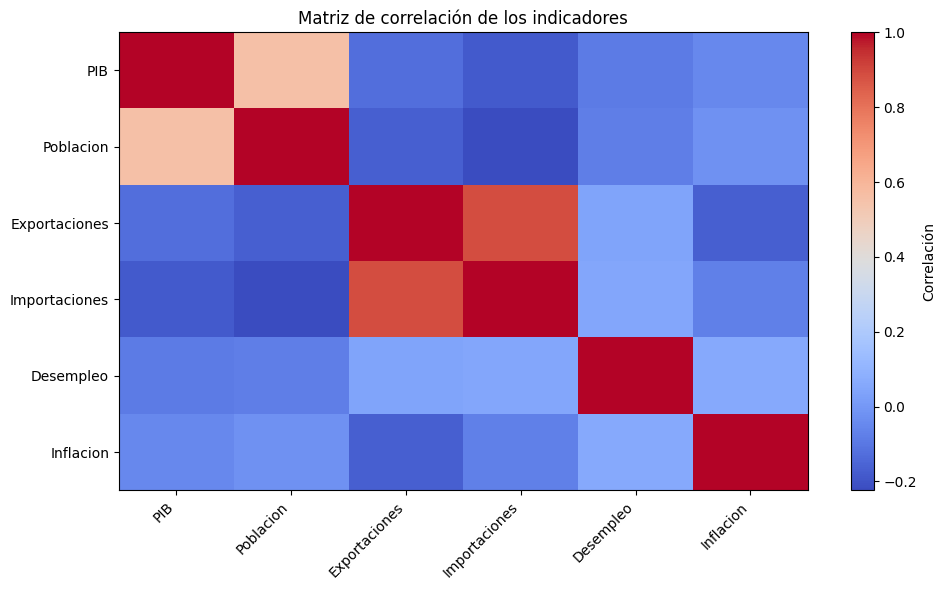

In [15]:
plt.figure(figsize=(10, 6))

plt.imshow(correlacion, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlación")

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

plt.title("Matriz de correlación de los indicadores")

plt.tight_layout()
plt.show()

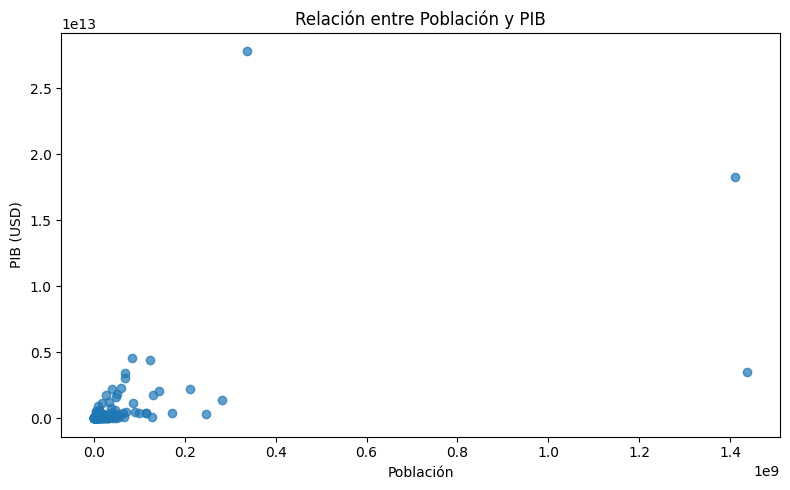

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_paises["Poblacion"],
    df_paises["PIB"],
    alpha=0.7
)

plt.xlabel("Población")
plt.ylabel("PIB (USD)")
plt.title("Relación entre Población y PIB")

plt.tight_layout()
plt.show()

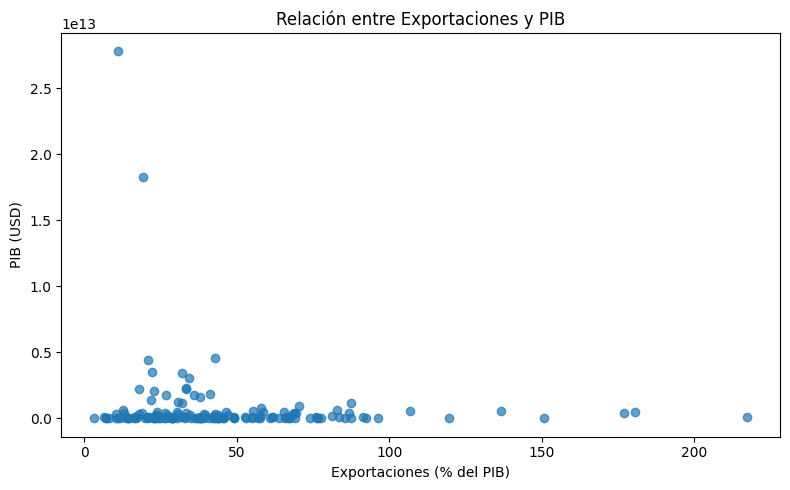

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_paises["Exportaciones"],
    df_paises["PIB"],
    alpha=0.7
)

plt.xlabel("Exportaciones (% del PIB)")
plt.ylabel("PIB (USD)")
plt.title("Relación entre Exportaciones y PIB")

plt.tight_layout()
plt.show()

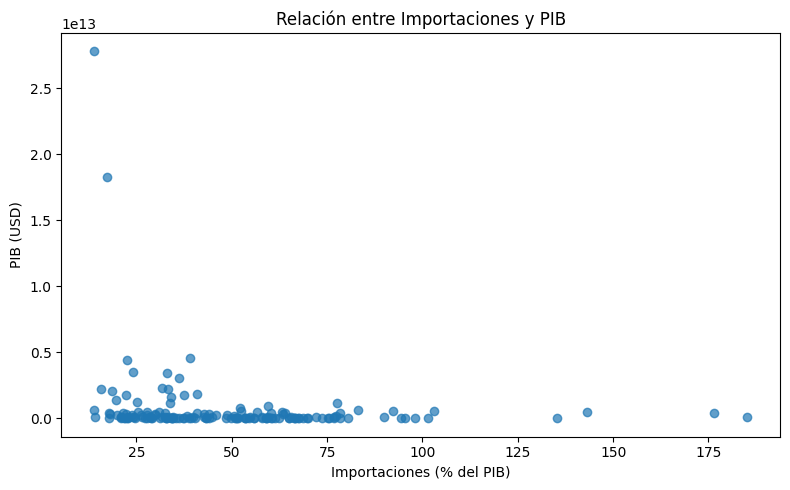

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_paises["Importaciones"],
    df_paises["PIB"],
    alpha=0.7
)

plt.xlabel("Importaciones (% del PIB)")
plt.ylabel("PIB (USD)")
plt.title("Relación entre Importaciones y PIB")

plt.tight_layout()
plt.show()

## 5. Análisis exploratorio de los datos

El análisis exploratorio permitió identificar las principales características y relaciones entre las variables seleccionadas. Las estadísticas descriptivas muestran diferencias importantes en la magnitud de los indicadores entre los países y economías analizados, especialmente en variables como el PIB y la población.

La matriz de correlación permite observar las relaciones lineales entre las variables. En particular, se analiza la relación del PIB con la población, las exportaciones, las importaciones, el desempleo y la inflación. Estas relaciones sirven como referencia inicial para la construcción del modelo de regresión lineal múltiple.

Los gráficos de dispersión permiten visualizar la distribución de los datos y detectar posibles patrones, concentraciones y valores extremos. La relación entre PIB y población resulta especialmente relevante debido a que ambas variables representan, en diferentes dimensiones, el tamaño de las economías.

Los resultados del análisis exploratorio constituyen una primera aproximación al comportamiento de los datos. Sin embargo, la correlación entre variables no implica una relación causal. Por esta razón, las variables serán evaluadas conjuntamente mediante un modelo


In [19]:
X = df_paises[
    [
        "Poblacion",
        "Exportaciones",
        "Importaciones",
        "Desempleo",
        "Inflacion"
    ]
]

y = df_paises["PIB"]

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(y.name)

Variables predictoras:
['Poblacion', 'Exportaciones', 'Importaciones', 'Desempleo', 'Inflacion']

Variable objetivo:
PIB


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", len(X_train))
print("Datos de prueba:", len(X_test))

Datos de entrenamiento: 120
Datos de prueba: 30


In [21]:
modelo = LinearRegression()

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


**Calcular las métricas**

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Métricas del modelo")
print("--------------------")
print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

Métricas del modelo
--------------------
MAE:  987,607,462,377.57
MSE:  4,257,150,579,057,866,024,419,328.00
RMSE: 2,063,286,354,110.32
R²:   0.6333


In [23]:
metricas = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²"],
    "Valor": [mae, mse, rmse, r2]
})

metricas

,Métrica,Valor
0,MAE,9.876075e+11
1,MSE,4.257151e+24
2,RMSE,2.063286e+12
3,R²,6.332767e-01


In [24]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})

coeficientes

,Variable,Coeficiente
0,Poblacion,5.570377e+03
1,Exportaciones,9.040080e+09
2,Importaciones,-1.773811e+10
3,Desempleo,-2.053246e+10
4,Inflacion,-2.411009e+09


In [25]:
print("Intercepto del modelo:", modelo.intercept_)

Intercepto del modelo: 965190768680.3655


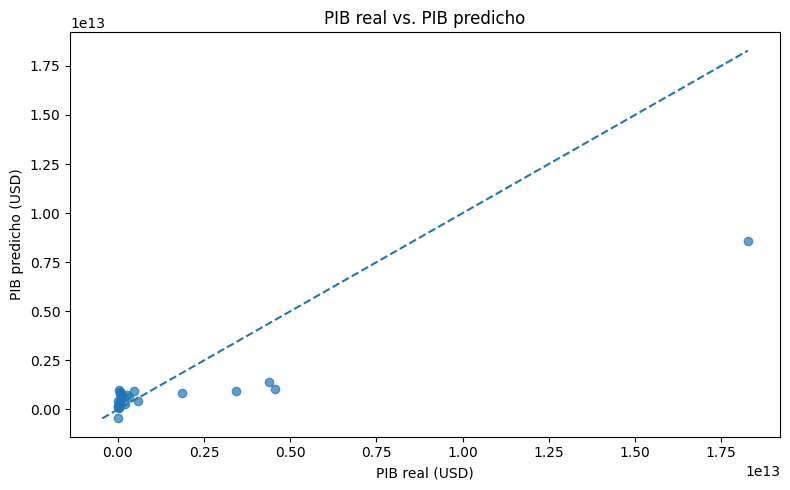

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.xlabel("PIB real (USD)")
plt.ylabel("PIB predicho (USD)")
plt.title("PIB real vs. PIB predicho")

# Línea de referencia
limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [27]:
residuos = y_test - y_pred

print("Residuos calculados correctamente.")

Residuos calculados correctamente.


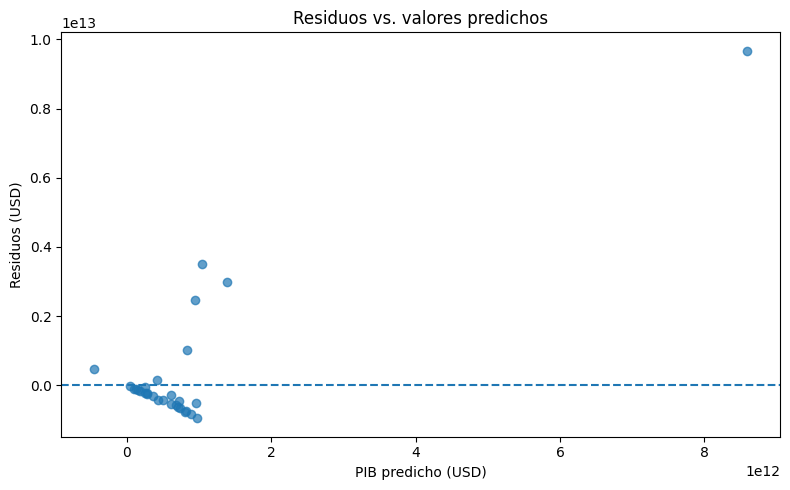

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuos,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("PIB predicho (USD)")
plt.ylabel("Residuos (USD)")
plt.title("Residuos vs. valores predichos")

plt.tight_layout()
plt.show()

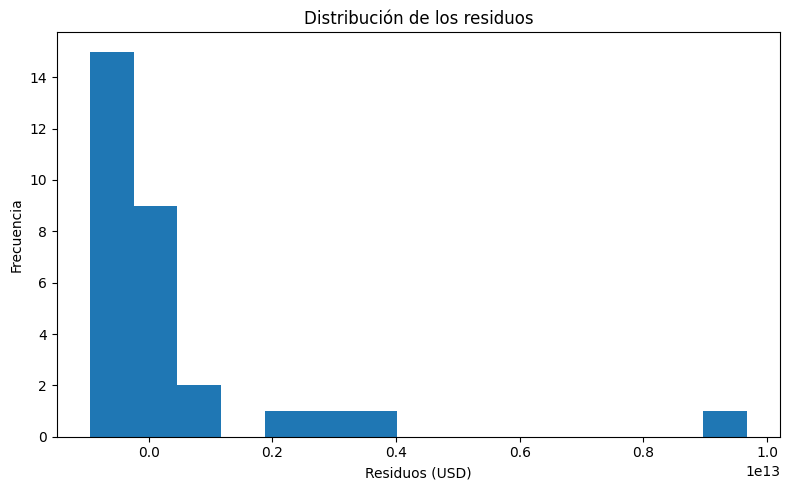

In [29]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuos,
    bins=15
)

plt.xlabel("Residuos (USD)")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")

plt.tight_layout()
plt.show()

## 6. Validación de los supuestos del modelo

La validación del modelo se realizó mediante la comparación entre los valores reales y los valores predichos, el análisis de los residuos frente a las predicciones y la distribución de los residuos.

La gráfica de valores reales frente a valores predichos permite evaluar visualmente la correspondencia entre las observaciones y las estimaciones realizadas por el modelo.

El gráfico de residuos frente a valores predichos se utilizó para revisar la presencia de patrones en los errores y evaluar visualmente el supuesto de homoscedasticidad. Una distribución de residuos alrededor de cero y sin patrones sistemáticos sería consistente con un comportamiento esperado para este supuesto.

Finalmente, el histograma de residuos permite observar su distribución y detectar posibles valores extremos o asimetrías.

Estas comprobaciones son principalmente gráficas y deben interpretarse junto con las características del conjunto de datos. Debido a que el PIB presenta diferencias importantes de escala entre países y economías, pueden existir patrones y valores extremos que limiten el ajuste de un modelo lineal simple.


In [30]:
df_paises.to_csv(
    "dataset_regresion_pib_2023_limpio.csv",
    index=False,
    encoding="utf-8"
)

print("Dataset guardado correctamente.")

Dataset guardado correctamente.


In [31]:
import os

print(os.path.exists("dataset_regresion_pib_2023_limpio.csv"))

True


In [32]:
%%writefile requirements.txt
pandas
numpy
requests
scikit-learn
matplotlib

Writing requirements.txt


In [33]:
!cat requirements.txt

pandas
numpy
requests
scikit-learn
matplotlib


In [37]:
%%writefile README.md

Writing README.md



# Predicción del Producto Interno Bruto mediante Regresión Lineal

## Semana 4 – Taller: Herramientas de Recolección de Datos

## 1. Descripción del proyecto

Este proyecto desarrolla un modelo de **Regresión Lineal Múltiple** para analizar en qué medida algunas variables demográficas y económicas permiten explicar y predecir el Producto Interno Bruto (PIB) de diferentes países y economías.

Los datos corresponden al año **2023** y fueron obtenidos mediante la **API oficial del Banco Mundial**, utilizando indicadores del conjunto **World Development Indicators (WDI)**.

El proyecto comprende las etapas de definición del problema, recolección de datos, limpieza, análisis exploratorio, construcción del modelo, evaluación y validación gráfica de los residuos.

---

## 2. Pregunta de investigación

**¿En qué medida algunas variables demográficas y económicas permiten explicar y predecir el PIB de los países?**

---

## 3. Objetivo

Construir y evaluar un modelo de **Regresión Lineal Múltiple** utilizando el PIB como variable objetivo y cinco indicadores demográficos y económicos como variables predictoras.

---

## 4. Variables utilizadas

| Variable | Código Banco Mundial | Descripción | Tipo |
|---|---|---|---|
| PIB | NY.GDP.MKTP.CD | Producto Interno Bruto en dólares corrientes | Variable objetivo |
| Población | SP.POP.TOTL | Población total | Predictora |
| Exportaciones | NE.EXP.GNFS.ZS | Exportaciones de bienes y servicios como % del PIB | Predictora |
| Importaciones | NE.IMP.GNFS.ZS | Importaciones de bienes y servicios como % del PIB | Predictora |
| Desempleo | SL.UEM.TOTL.ZS | Desempleo como % de la fuerza laboral | Predictora |
| Inflación | FP.CPI.TOTL.ZG | Variación porcentual anual del índice de precios al consumidor | Predictora |

---

## 5. Fuente y recolección de datos

La fuente principal de información es el **Banco Mundial – World Development Indicators (WDI)**.

Los datos fueron recolectados mediante la **API de Indicadores del Banco Mundial**, utilizando Python y la biblioteca `requests`.

Se consultó el año **2023** para cada uno de los seis indicadores seleccionados.

Posteriormente, los resultados fueron transformados en estructuras `DataFrame` mediante `pandas` y combinados utilizando el código y nombre de cada país o economía como claves.

La utilización de una API permite mantener la trazabilidad del proceso de recolección y facilita la reproducción del proyecto.

Fuente:

https://data.worldbank.org/

Documentación de la API:

https://datahelpdesk.worldbank.org/knowledgebase/articles/889392

---

## 6. Preparación y limpieza de los datos

Durante la revisión inicial se identificó que la consulta general de la API puede incluir tanto países y economías individuales como registros correspondientes a regiones y grupos económicos.

Para evitar que estos agregados formaran parte del análisis, se consultó la clasificación disponible en la API del Banco Mundial y se conservaron los registros correspondientes a países y economías identificados por dicha clasificación.

También se verificaron:

- Valores faltantes.
- Registros duplicados.
- Estructura y tipos de datos.
- Consistencia de las variables seleccionadas.

El conjunto resultante fue utilizado para el análisis exploratorio y la construcción del modelo de regresión.

---

## 7. Análisis exploratorio de datos

El análisis exploratorio incluyó:

- Estadísticas descriptivas.
- Matriz de correlación.
- Mapa de correlaciones.
- Gráfico de dispersión entre PIB y población.
- Gráfico de dispersión entre PIB y exportaciones.
- Gráfico de dispersión entre PIB e importaciones.

Las estadísticas descriptivas permitieron identificar diferencias importantes en la magnitud de los indicadores entre los países y economías analizados.

La matriz de correlación permitió observar las relaciones lineales entre el PIB y las variables predictoras.

Los gráficos de dispersión permitieron visualizar patrones generales, concentración de observaciones y posibles valores extremos.

Las relaciones identificadas mediante correlación se consideran asociaciones estadísticas y no implican causalidad.

---

## 8. Construcción del modelo

Se construyó un modelo de **Regresión Lineal Múltiple** utilizando:

### Variable objetivo

- PIB

### Variables predictoras

- Población
- Exportaciones
- Importaciones
- Desempleo
- Inflación

Los datos fueron divididos en:

- **80 % para entrenamiento**
- **20 % para prueba**

Se utilizó `random_state=42` para facilitar la reproducibilidad de los resultados.

El modelo fue implementado mediante la clase `LinearRegression` de la biblioteca `scikit-learn`.

---

## 9. Evaluación del modelo

El modelo fue evaluado mediante las siguientes métricas:

- **MAE:** Error Absoluto Medio.
- **MSE:** Error Cuadrático Medio.
- **RMSE:** Raíz del Error Cuadrático Medio.
- **R²:** Coeficiente de determinación.

Los valores definitivos de las métricas se encuentran registrados en el notebook después de ejecutar el modelo.

Se evita incorporar valores manualmente en este README para mantener la consistencia con la ejecución final del proyecto.

---

## 10. Validación de supuestos

La validación gráfica del modelo incluyó:

### PIB real vs. PIB predicho

Permite comparar los valores observados con las estimaciones realizadas por el modelo.

### Residuos vs. valores predichos

Permite revisar visualmente la distribución de los errores y detectar posibles patrones relacionados con la linealidad y la homoscedasticidad.

### Histograma de residuos

Permite observar la distribución de los errores e identificar posibles asimetrías o valores extremos.

Estas comprobaciones son principalmente gráficas y deben interpretarse teniendo en cuenta las características del conjunto de datos.

---

## 11. Limitaciones

El proyecto presenta las siguientes limitaciones:

- El análisis utiliza información correspondiente a un solo año: 2023.
- El PIB presenta diferencias de escala importantes entre países y economías.
- El modelo utiliza únicamente cinco variables predictoras.
- Pueden existir valores extremos que influyan en el ajuste.
- La regresión lineal supone relaciones lineales entre las variables.
- Las asociaciones estadísticas encontradas no deben interpretarse como relaciones causales.
- El conjunto de prueba representa una cantidad limitada de observaciones.

---

## 12. Futuras mejoras

Como posibles líneas de trabajo se plantean:

- Incorporar información de varios años.
- Ampliar el número de variables económicas, sociales y demográficas.
- Aplicar transformaciones a variables con distribuciones altamente asimétricas.
- Comparar la regresión lineal con otros algoritmos de aprendizaje automático.
- Implementar validación cruzada.
- Analizar y tratar de manera más específica los valores extremos.
- Evaluar modelos utilizando transformaciones logarítmicas del PIB.

---

## 13. Estructura del repositorio

```text
proyecto_regresion_pib/
│
├── datos/
│   └── dataset_regresion_pib_2023_limpio.csv
│
├── notebooks/
│   └── regresion_lineal_pib_2023.ipynb
│
├── informe/
│   └── Informe_RegresionLineal_RivasYerson.pdf
│
├── README.md
└── requirements.txt

In [35]:
pip install -r requirements.txt

Fuentes y referencias

**Fuente de datos**

World Bank – World Development Indicators (WDI)

https://datatopics.worldbank.org/world-development-indicators/

World Bank – Indicators API Documentation

https://datahelpdesk.worldbank.org/knowledgebase/articles/889392

World Bank – Indicator API Queries

https://datahelpdesk.worldbank.org/knowledgebase/articles/898599

**Fuente académica**

Universidad de Cundinamarca.

Introducción al Machine Learning: Una Guía Práctica.

https://posgrado.ucundinamarca.edu.co/pluginfile.php/79242/mod_label/intro/Introduccion-al-Machine-Learning-Una-Guia-Practica.pdf

**Documentación técnica**

Scikit-learn.

Getting Started — scikit-learn documentation.

https://scikit-learn.org/stable/getting_started.html

**Recursos audiovisuales**

Learning Scikit-Learn

https://www.youtube.com/watch?v=rvVkVsG49uU

Tutorial: ¡SCIKIT-LEARN DESDE CERO!

https://www.youtube.com/watch?v=qUjIybMkXBs

Autor

Yerson Ronaldo Rivas Ruiz

Especialización en Análisis y Ciencia de Datos

In [36]:
!head -20 README.md

head: cannot open 'README.md' for reading: No such file or directory


In [38]:
from google.colab import files

files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>